### 1. Import necessary libraries

In [1]:
import os, h5py, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

### 2. Check activations for all layers

In [2]:
data_dir = "../results/baseline/activations_32b.h5"

# Peek into the structure of the HDF5 file to understand how the data is organized
with h5py.File(data_dir, "r") as f_in:
    print("Inside emotional:", list(f_in["emotional"].keys()))
    print("Inside emotions [Eg. Angry]:", list(f_in["emotional"]["angry"].keys()))
    print("Inside neutral:", list(f_in["neutral"].keys()))

Inside emotional: ['afraid', 'angry', 'calm', 'desperate', 'guilty', 'happy', 'inspired', 'loving', 'nervous', 'proud', 'sad', 'surprised']
Inside emotions [Eg. Angry]: ['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']
Inside neutral: ['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']


### 3. Open the file, read and save the activations for further analysis

In [3]:
inspect_layer = "layer_42"

# Load emotional and neutral activations for the specified layer
with h5py.File(data_dir, "r") as f_in:
    emotional_activations = {}
    for emotion in f_in["emotional"]:
        emotional_activations[emotion] = f_in[f"emotional/{emotion}/{inspect_layer}"][:]
    
    neutral_activations = f_in[f"neutral/{inspect_layer}"][:]
print("Emotional activations shape:", {emotion: activation.shape for emotion, activation in emotional_activations.items()})
print("Neutral activations shape:", neutral_activations.shape)

Emotional activations shape: {'afraid': (192, 5120), 'angry': (190, 5120), 'calm': (192, 5120), 'desperate': (192, 5120), 'guilty': (192, 5120), 'happy': (190, 5120), 'inspired': (192, 5120), 'loving': (192, 5120), 'nervous': (191, 5120), 'proud': (191, 5120), 'sad': (191, 5120), 'surprised': (190, 5120)}
Neutral activations shape: (48, 5120)


### 4.  Run PCA on the neutral activations

In [4]:
neutral_centered = neutral_activations - neutral_activations.mean(axis=0, keepdims=True)
pca = PCA()
pca.fit(neutral_centered)
running_sum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.searchsorted(running_sum, 0.50) + 1
neutral_pcs = pca.components_[:n_components]
print(f"Number of PCA components to retain 50% variance: {n_components}")

Number of PCA components to retain 50% variance: 1


#### Define functions

In [5]:
def normalize(v, eps=1e-8):
    return v / (np.linalg.norm(v) + eps)

def project_out_neutral_pcs(emotion, emotional_activations,
                        all_emotion_mean, 
                        pca_components):
    # Compute mean activation across stories for the emotion
    emotion_vec = np.mean(emotional_activations[emotion], axis=0) - all_emotion_mean
    for pc in pca_components:
        emotion_vec = emotion_vec - np.dot(emotion_vec, pc) * pc
    return normalize(emotion_vec)

### 5. Extract the emotion vectors by projecting out the neutral PCs

In [6]:
all_emotion_mean = np.mean([np.mean(emotional_activations[emotion], axis=0) for emotion in emotional_activations], axis=0)
processed_emotions = {}
for emotion in emotional_activations:
    processed_emotions[emotion] = project_out_neutral_pcs(emotion, emotional_activations, all_emotion_mean, neutral_pcs)
print("Processed emotional activations shape:", {emotion: activation.shape for emotion, activation in processed_emotions.items()})
print("Norms:", {emotion: np.linalg.norm(v) for emotion, v in processed_emotions.items()})

Processed emotional activations shape: {'afraid': (5120,), 'angry': (5120,), 'calm': (5120,), 'desperate': (5120,), 'guilty': (5120,), 'happy': (5120,), 'inspired': (5120,), 'loving': (5120,), 'nervous': (5120,), 'proud': (5120,), 'sad': (5120,), 'surprised': (5120,)}
Norms: {'afraid': np.float32(1.0), 'angry': np.float32(0.99999994), 'calm': np.float32(1.0), 'desperate': np.float32(1.0), 'guilty': np.float32(1.0), 'happy': np.float32(1.0), 'inspired': np.float32(0.99999994), 'loving': np.float32(0.99999994), 'nervous': np.float32(0.99999994), 'proud': np.float32(1.0), 'sad': np.float32(1.0), 'surprised': np.float32(1.0)}


### 6. Plot them!!! 

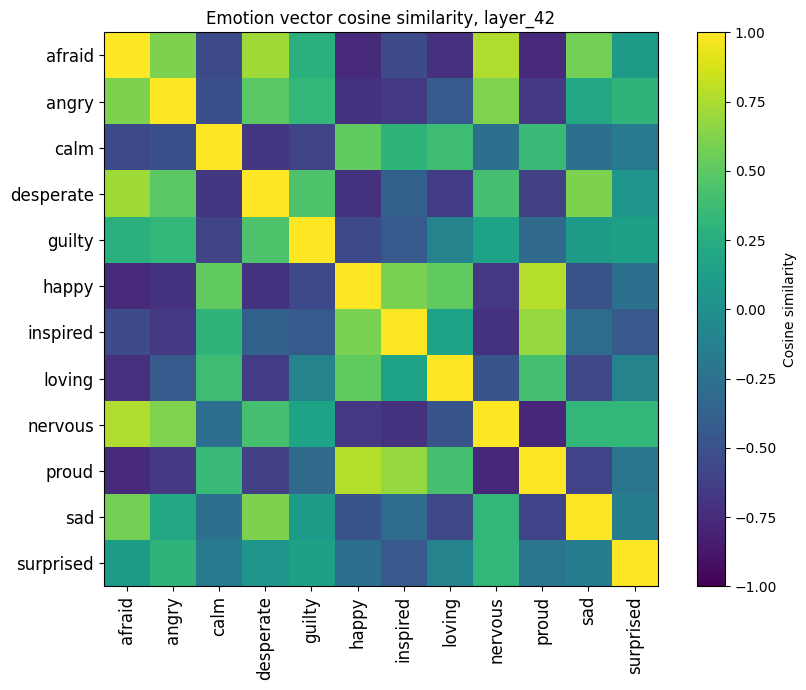

In [10]:
emotions = list(processed_emotions.keys())
V = np.stack([processed_emotions[e] for e in emotions])

cos_sim = cosine_similarity(V)

plt.figure(figsize=(9, 7))
plt.imshow(cos_sim, vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(emotions)), emotions, rotation=90, fontsize=12)
plt.yticks(range(len(emotions)), emotions, fontsize=12)
plt.title(f"Emotion vector cosine similarity, {inspect_layer}", fontsize=12)
plt.tight_layout()
plt.show()

Explained variance ratio: [0.51997405 0.13550483]
Total variance explained: 0.6554789


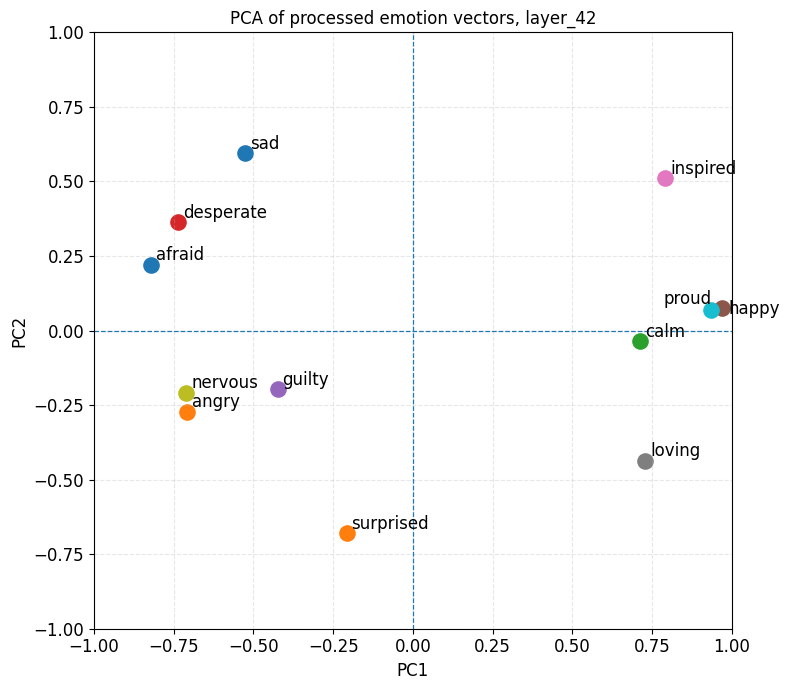

In [51]:

# Stack emotion vectors
emotions = list(processed_emotions.keys())
V = np.stack([processed_emotions[e] for e in emotions])

# PCA to 2D
pca = PCA(n_components=2)
V_2d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(8, 7))

for i, emotion in enumerate(emotions):
    x, y = V_2d[i]
    plt.scatter(x, y, s=120)
    if emotion not in ["happy", "proud"]:
        plt.text(x + 0.015, y + 0.015, emotion, fontsize=12)
    elif emotion == "proud":
        plt.text(x - 0.15, y + 0.02, emotion, fontsize=12)
    else:
        plt.text(x + 0.02, y - 0.018, emotion, rotation=0, fontsize=12)


plt.axhline(0, linewidth=0.9, linestyle="--")
plt.axvline(0, linewidth=0.9, linestyle="--")

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title(f"PCA of processed emotion vectors, {inspect_layer}", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### And it works!!!!!